discriminant analysis is for categorical

predictors have to be continuous

dimensionality reduction

with as little information loss

1000 predictors high dimensional data

funciones discimantes

dimension reduction to achive its goal -> classification

continuous predictors

3 colores en un plano

the data becomes more sparse

the algorithm is more likely to learn form exceptional cases, overfit and have a lot of variance in their predictions.

the number of cases would need to grow exponentially to mantain the same density

dimension reduction.

Hughes phenomenon

trata de projector al major espacio entre clases!

separates the centroid of each class while keeping the within class variance as low as possible
a un punto

a vector of means one for each dimension!


(x1 - x2)² centroides en el plano projectado!
/
varianze of class 1 along the line s1² s2²

si haces chiquitp abajo se hace grande el numero.

toma en cuanta las dos, controlas las dos por separado con derivadas.

max($\frac{(\bar{x}_1 - \bar{x}_2)^2}{s_1^2 + s_2^2}$)

esas mediciones son de las projecciones que primero se projectan los puntos a la linea y despues se miden los promedios y las varianzas y se mide el error,  despues se deriva y se maximiza la distancia L2 dividida entre la suma de las varianzas cuadraticas.

discriminant function axis.

es una combinacion lineal de las variables!

canonical discriminant function coefficients

larger absolute value cannonical coefficients

it doesnt rely on labelled data

create new axes para nueva data y clasificar esa data
en base a esos axes

pca no hace eso no crea axes solo clasifica la data original y ya

si ya tienes clases usa LDA
si no tienes clases usa PCA

once the first discrimant function is found, the second is found that is ortogonal to it entonces esta formando una base!

es un cambio de 

clases - 1 = 2

predictor variables = 2

no reduction if 2 variables

number of DFs 2

------------------

min = 2 ejes

classes 3 - 1 = 2

variables = 3

predictors son gaussianos!

regression


curved lines

non linear decision boundaries

likelihood p(x|k)

posterior probability p(k|x) sum to 1

p(k) prior probability

p(x) evidence no se puede

la posterior es proporcional a el likelihood por la prior

p(k|x) proporcianal p(x|k) * p(k)

proportion of cases in the dataset 
that belong to class k

the probability density 




In [1]:
library(mlr)

Loading required package: ParamHelpers



In [2]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
data(wine, package = 'HDclassif')

In [4]:
wine

class,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045


In [5]:
winetib<-as_tibble(wine)

In [6]:
names(winetib) <- c(
    'Class',
    'Alco',
    'Malic',
    'Ash',
    'Alk',
    'Mag',
    'Phe',
    'Flav','Non_flav','Proan','Col','Hue','OD','Prol')

In [12]:
winetib$Class <- as.factor(winetib$Class)

In [13]:
winetib

Class,Alco,Malic,Ash,Alk,Mag,Phe,Flav,Non_flav,Proan,Col,Hue,OD,Prol
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045


In [15]:
#viendo las propiedades quieres ver de que viñedo viene el vino?

In [33]:
wineuntidy<-gather(winetib, 'Variable','Value', -Class)
wineuntidy

Class,Variable,Value
<fct>,<chr>,<dbl>
1,Alco,14.23
1,Alco,13.20
1,Alco,13.16
1,Alco,14.37
1,Alco,13.24
1,Alco,14.20
1,Alco,14.39
1,Alco,14.06
1,Alco,14.83


Saving 6.67 x 6.67 in image


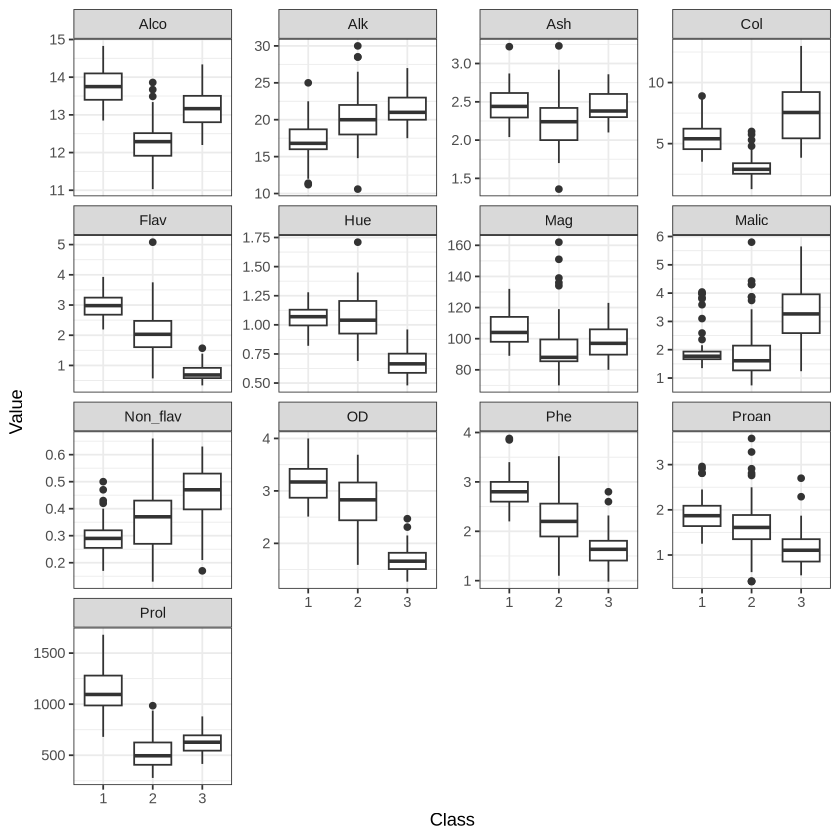

In [39]:
(
    ggplot(wineuntidy, aes(Class,Value)) + 
    facet_wrap(~Variable, scales = 'free_y') + 
    geom_boxplot() + 
    theme_bw()
)
ggsave('all.png')